# Data Preparation

Import and analyse the dataset to clean up possible problematic features.


In [ ]:
import pandas as pd
import numpy as np
import functions as uf

%load_ext autoreload
%autoreload 2

data_folder = "dataset/"

df_artist = pd.read_csv(data_folder + "artists.csv", sep=";")
df_track = pd.read_csv(data_folder + "tracks.csv", sep=",")
df_artist.head()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,active_end,province,region,country,latitude,longitude
0,ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,NaN,NaN,NaN,NaN
1,ART53496045,achille lauro,M,1990-07-11,Verona,Italia,cantautore e rapper italiano (1990-),2012-01-01,NaN,Verona,Veneto,Italia,45.442498,10.985738
2,ART18853907,alfa,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ART64265460,anna pepe,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ART75741740,articolo 31,M,NaN,NaN,NaN,gruppo musicale hip hop italiano,1990-01-01,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:

df_track.head()

,id,id_artist,name_artist,full_title,title,featured_artists,primary_artist,language,album,stats_pageviews,...,album_type,disc_number,track_number,duration_ms,explicit,popularity,album_image,id_album,lyrics,modified_popularity
0,TR934808,ART04205421,Rosa Chemical,​polka 2 :-/ by Rosa Chemical (Ft. Ernia & Guè),​polka 2 :-/,"Ernia, Guè",Rosa Chemical,pl,FOREVER AND EVER,196033.0,...,album,1.0,3.0,207761.0,True,46.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Oplà, ah\nBdope, chiama due b—\n\nMi candidere...",False
1,TR760029,ART04205421,Rosa Chemical,POLKA by Rosa Chemical (Ft. Thelonious B.),POLKA,Thelonious B.,Rosa Chemical,en,FOREVER AND EVER,164450.0,...,album,1.0,3.0,207761.0,True,46.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Greg Willen, non dormire\n(Brr-poh)\n\nT-T-Tro...",False
2,TR916821,ART04205421,Rosa Chemical,​britney ;-) by Rosa Chemical (Ft. MamboLosco ...,​britney ;-),"MamboLosco, RADICAL",Rosa Chemical,en,FOREVER AND EVER,58313.0,...,album,1.0,1.0,193544.0,True,39.0,https://i.scdn.co/image/ab67616d0000b2736d5e14...,ALB115557,"Mothz\nYeah, yeah, yeah-yeah\nBdope, chiama du...",False
3,TR480968,ART04205421,Rosa Chemical,CEO by Rosa Chemical (Ft. Taxi B),CEO,Taxi B,Rosa Chemical,it,OKAY OKAY !! - EP,39890.0,...,single,1.0,2.0,169000.0,True,47.0,https://i.scdn.co/image/ab67616d0000b27367c03d...,ALB730959,Designer sui vestiti penso di essere un outlet...,False
4,TR585039,ART04205421,Rosa Chemical,LONDRA by Rosa Chemical (Ft. Rkomi),LONDRA,Rkomi,Rosa Chemical,en,FOREVER AND EVER,35432.0,...,album,1.0,8.0,194779.0,True,41.0,https://i.scdn.co/image/ab67616d0000b273fcdb60...,ALB436151,"Bdope (Yeah)\n\nVuole solo me, non fare la gel...",False


Merge the Dataset by using artist ids.

In [61]:
df = pd.merge(df_artist, df_track, left_on="id_author", right_on="id_artist", validate="one_to_many")
df = df.rename(columns={"id": "id_song"})
df.full_title.value_counts(), df.name.unique().value_counts()
print(f"Number of unique full titles after merge: {df.full_title.nunique()} vs original {df_track.full_title.nunique()}")
print(f"Number of unique names after merge: {df.name.nunique()} vs original {df_artist.name.nunique()}")
df.head()

Number of unique full titles after merge: 11164 vs original 11164
Number of unique names after merge: 104 vs original 104


,id_author,name,gender,birth_date,birth_place,nationality,description,active_start,active_end,province,...,album_type,disc_number,track_number,duration_ms,explicit,popularity,album_image,id_album,lyrics,modified_popularity
0,ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,...,album,1.0,2.0,323360.0,False,49.0,https://i.scdn.co/image/ab67616d0000b273dd9d76...,ALB129072,22.9.1991\nUn giorno come tanti ma non certo p...,False
1,ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,...,album,1.0,5.0,354506.0,False,47.0,https://i.scdn.co/image/ab67616d0000b273dd9d76...,ALB129072,"Fichettini inamidati tutti turgidi, induriti\n...",False
2,ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,...,album,1.0,4.0,267333.0,False,42.0,https://i.scdn.co/image/ab67616d0000b273dd9d76...,ALB129072,Damme 'o documento ca si no poi t'allamiente\n...,False
3,ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,...,album,1.0,5.0,252760.0,False,47.0,https://i.scdn.co/image/ab67616d0000b27389306e...,ALB947801,È inutile cercare un perché\nNon c'è mai stato...,False
4,ART82291002,99 posse,M,NaN,NaN,NaN,gruppo musicale italiano,1991-01-01,NaN,NaN,...,album,1.0,9.0,213506.0,False,44.0,https://i.scdn.co/image/ab67616d0000b273f34fe5...,ALB360392,"Quando ho visto il posto di blocco, ho fatto q...",False


We have a album and album_name entry. We can check the similarity among those features and decide that we could drop one of them. We may do this with fuzzy string similarity. We do this only among entries with no empty values.

In [62]:
print(f"NaN in 'album': {df['album'].isna().sum()}")
print(f"NaN in 'album_name': {df['album_name'].isna().sum()}")
comparison, score_avg = uf.compare_text_columns(df, "album", "album_name")
print(f"Rows evaluated: {len(comparison)}")
print(f"Average similarity score: {score_avg:.2f}")
comparison.head()

NaN in 'album': 1514
NaN in 'album_name': 78
Rows evaluated: 9579
Average similarity score: 79.88


,album,album_name,similarity_score
0,Curre Curre Guagliò,Curre curre guagliò,100.000000
1,Curre Curre Guagliò,Curre curre guagliò,100.000000
2,Curre Curre Guagliò,Curre curre guagliò,100.000000
3,Corto circuito,Corto circuito,100.000000
4,Curre curre guaglió 2.0: Non un passo indietro,Curre Curre Guagliò 2.0,56.140351


This can also be done for "tile" and "full_title".

In [63]:
print(f"Unique values in 'title': {df['title'].nunique()} vs 'full_title': {df['full_title'].nunique()}")
comparison, score_avg = uf.compare_text_columns(df, "title", "full_title")
print(f"Rows evaluated: {len(comparison)}")
print(f"Average similarity score: {score_avg:.2f}")
comparison.head()

Unique values in 'title': 10521 vs 'full_title': 11164
Rows evaluated: 11166
Average similarity score: 98.73


,title,full_title,similarity_score
0,Curre Curre Guagliò,Curre Curre Guagliò by 99 Posse,100.000000
1,Rigurgito Antifascista,Rigurgito Antifascista by 99 Posse (Ft. Speake...,100.000000
2,O’ documento,O' documento by 99 Posse,85.714286
3,Quello che,Quello che by 99 Posse,100.000000
4,Giovanotto documenti,Giovanotto documenti by 99 Posse (Ft. Caparezz...,100.000000


We drop "album" since it has more empty values than album_name. title and full_title have no empty values but full_title has only unique values, so we decide to drop "title".

In [64]:
df.drop(columns=["album", "title"], inplace=True)

Evaluate missing values, duplicated records, inconsistent values, incorrect dates, extreme
values (OOD)

<Axes: title={'center': 'Top 15 Missing Features (%)'}, ylabel='feature'>

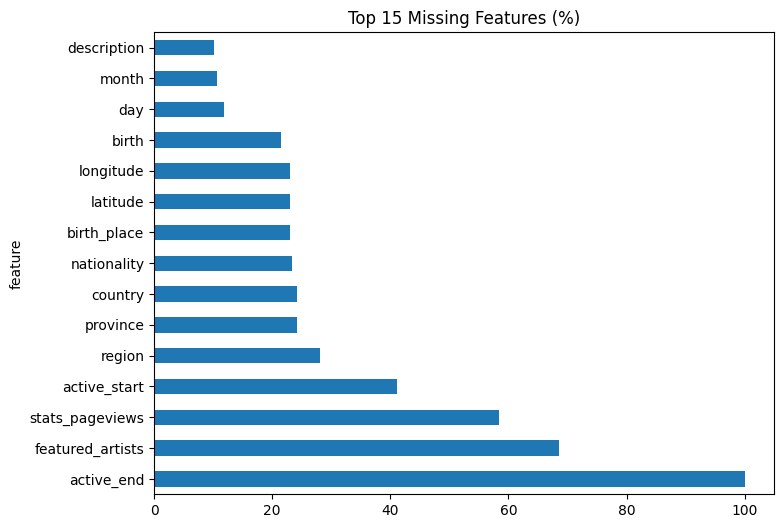

In [67]:
# Replace empty strings with NaN
df = df.replace(r'^\s*$', np.nan, regex=True)

# Artist variables missing values
missing_values_artist = {"birth": df.birth_date.isna().sum(),
                         "birth_place": df.birth_place.isna().sum(),
                         "nationality": df.nationality.isna().sum(),
                         "province": df.province.isna().sum(),
                         "region": df.region.isna().sum(),
                         "country": df.country.isna().sum(),
                         "latitude": df.latitude.isna().sum(),
                         "longitude": df.longitude.isna().sum(),
                         "active_start": df.active_start.isna().sum(),
                         "active_end": df.active_end.isna().sum(),
                         "description": df.description.isna().sum()}

# Release date variables missing values
missing_values_album_release_date = {"date": df.album_release_date.isna().sum(),
                                     "year": df.year.isna().sum(),
                                     "month": df.month.isna().sum(),
                                     "day": df.day.isna().sum()}

# Numeric audio features missing values
missing_values_audio_features = {"bpm": df.bpm.isna().sum(),
                                 "centroid": df.centroid.isna().sum(),
                                 "rolloff": df.rolloff.isna().sum(),
                                 "flux": df.flux.isna().sum(),
                                 "zero_crossing_rate": df.zcr.isna().sum(),
                                 "flatness": df.flatness.isna().sum(),
                                 "spectral_complexity": df.spectral_complexity.isna().sum(),
                                 "pitch": df.pitch.isna().sum(),
                                 "loudness": df.loudness.isna().sum()}

# Song variables missing values
missing_values_song = {"featured_artists": df.featured_artists.isna().sum(),
                       "language": df.language.isna().sum(),
                       "album_name": df.album_name.isna().sum(),
                       "album_type": df.album_type.isna().sum(),
                       "disc_number": df.disc_number.isna().sum(),
                       "track_number": df.track_number.isna().sum(),
                       "duration_ms": df.duration_ms.isna().sum(),
                       "stats_pageviews": df.stats_pageviews.isna().sum(),
                       "n_sentences": df.n_sentences.isna().sum(),
                       "n_words": df.n_tokens.isna().sum(),
                       "n_words_per_sentence": df.tokens_per_sent.isna().sum(),
                       "char_per_word": df.char_per_tok.isna().sum(),
                       "lexical_density": df.lexical_density.isna().sum(),
                       "n_words_per_clause": df.avg_token_per_clause.isna().sum(),
                       "explicit": df.explicit.isna().sum(),
                       "popularity": df.popularity.isna().sum(),
                       "lyrics": df.lyrics.isna().sum()}

# Build one tidy summary table
missing_summary = pd.concat([
    pd.DataFrame(list(missing_values_artist.items()), columns=["feature", "missing_count"]).assign(group="artist"),
    pd.DataFrame(list(missing_values_album_release_date.items()), columns=["feature", "missing_count"]).assign(group="release_date"),
    pd.DataFrame(list(missing_values_audio_features.items()), columns=["feature", "missing_count"]).assign(group="audio"),
    pd.DataFrame(list(missing_values_song.items()), columns=["feature", "missing_count"]).assign(group="song")
], ignore_index=True)

missing_summary["missing_pct"] = (100 * missing_summary["missing_count"] / len(df)).round(2)
missing_summary = missing_summary.sort_values(["missing_pct", "missing_count"], ascending=False).reset_index(drop=True)

# Pretty table
import matplotlib
missing_summary.style.background_gradient(subset=["missing_pct"], cmap="YlOrRd").format({"missing_pct": "{:.2f}%"})

# Optional quick visual for top missing features
missing_summary.head(15).plot.barh(x="feature", y="missing_pct", figsize=(8, 6), legend=False, title="Top 15 Missing Features (%)")